AI-Powered House Price Prediction and Real Estate Market Intelligence System

importing libraries and loading dataset

In [2]:
#basic libraries
import numpy as np
import pandas as pd
#
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\houseprice prediction\housing_price_dataset.csv")

dataset dimensions

In [4]:
print(df.shape)

(50000, 30)


The dataset contains 50,000 house records and 29 features. The target variable is price_in_lakhs, making this a supervised machine learning regression problem. The data covers major Indian metropolitan cities including Bangalore, Mumbai, Delhi, and Hyderabad.

In [5]:
df.head()

,property_id,city,locality,locality_tier,property_type,bhk,bathrooms,balconies,built_up_area,carpet_area,...,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,transaction_type,price_in_lakhs,price_category
0,PROP-000001,Bangalore,HSR Layout,Standard,Apartment,4,4,1,1570,1361,...,1,0,3094,11.6,3.5,3,1,New,102.34,Low
1,PROP-000002,Mumbai,Powai,Standard,Row House,2,1,1,908,778,...,1,1,3893,24.2,1.3,3,2,Resale,71.48,Low
2,PROP-000003,Bangalore,Indiranagar,Premium,Independent House,3,3,2,1784,1568,...,1,1,7038,5.0,0.1,2,1,Resale,245.57,High
3,PROP-000004,Mumbai,Powai,Standard,Independent House,4,4,2,2318,2011,...,0,1,3569,11.9,7.9,2,0,New,122.95,Low
4,PROP-000005,Bangalore,Electronic City,Standard,Apartment,3,4,2,988,840,...,1,1,2628,11.4,7.2,1,0,Resale,64.71,Low


Dataset Details
Total Records: 50,000
Features: 29  Features
Target Variable:price_in_lakhs (Regression)
Cities:Bangalore
    Mumbai
    Delhi
    Hyderabad

missing value analysis

In [6]:
df.isnull().sum()

property_id                   0
city                          0
locality                      0
locality_tier                 0
property_type                 0
bhk                           0
bathrooms                     0
balconies                     0
built_up_area                 0
carpet_area                   0
floor_number                  0
total_floors                  0
floor_category                0
facing                        0
furnishing_status             0
property_age                  0
parking_spaces                0
security_score                0
gym_available                 0
swimming_pool                 0
power_backup                  0
lift_available                0
maintenance_fee_monthly       0
distance_to_city_center_km    0
distance_to_metro_km          0
nearby_schools                0
nearby_hospitals              0
transaction_type              0
price_in_lakhs                0
price_category                0
dtype: int64

checking duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

dataset structure and data types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 50000 non-null  str    
 1   city                        50000 non-null  str    
 2   locality                    50000 non-null  str    
 3   locality_tier               50000 non-null  str    
 4   property_type               50000 non-null  str    
 5   bhk                         50000 non-null  int64  
 6   bathrooms                   50000 non-null  int64  
 7   balconies                   50000 non-null  int64  
 8   built_up_area               50000 non-null  int64  
 9   carpet_area                 50000 non-null  int64  
 10  floor_number                50000 non-null  int64  
 11  total_floors                50000 non-null  int64  
 12  floor_category              50000 non-null  str    
 13  facing                      50000 non-null

dropping irrelevent features

In [9]:
df.drop("property_id", axis=1, inplace=True)

statistical summery of numerical analysis

In [10]:
df.describe()

,bhk,bathrooms,balconies,built_up_area,carpet_area,floor_number,total_floors,property_age,parking_spaces,security_score,gym_available,swimming_pool,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,price_in_lakhs
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.152220,3.363320,1.688440,1573.280760,1321.453680,9.321400,14.435200,6.512000,1.91362,6.004076,0.414860,0.299840,0.684920,0.838180,3984.119580,11.519852,2.506840,3.115700,1.903580,166.754386
std,1.216009,1.330742,1.236107,670.323353,564.290797,8.704547,8.814554,6.884051,1.44929,1.606905,0.492703,0.458192,0.464552,0.368289,1640.950213,5.434226,2.484553,1.899038,1.469465,104.716850
min,1.000000,1.000000,0.000000,300.000000,240.000000,0.000000,1.000000,0.000000,0.00000,0.100000,0.000000,0.000000,0.000000,0.000000,500.000000,4.000000,0.100000,0.000000,0.000000,10.000000
25%,2.000000,2.000000,1.000000,1044.000000,877.000000,3.000000,8.000000,2.000000,1.00000,4.900000,0.000000,0.000000,0.000000,1.000000,2681.000000,6.800000,0.700000,2.000000,1.000000,86.197500
50%,3.000000,3.000000,2.000000,1586.000000,1328.000000,7.000000,13.000000,4.000000,2.00000,5.900000,0.000000,0.000000,1.000000,1.000000,3672.000000,11.000000,1.700000,3.000000,2.000000,147.735000
75%,4.000000,4.000000,3.000000,2132.000000,1785.000000,14.000000,18.000000,9.000000,3.00000,7.100000,1.000000,1.000000,1.000000,1.000000,5190.000000,14.200000,3.500000,4.000000,3.000000,226.810000
max,5.000000,6.000000,4.000000,3092.000000,2697.000000,39.000000,45.000000,40.000000,5.00000,10.000000,1.000000,1.000000,1.000000,1.000000,8859.000000,45.000000,15.000000,10.000000,8.000000,785.620000


Descriptive statistics such as mean, median, standard deviation, minimum, and maximum values provide insights into the distribution and variability of numerical features in the dataset.

Statistical Hypothesis Testing

1.Pearson Correlation Test (Built-up Area vs House Price)

Purpose: Determine whether a numeric feature has a significant linear relationship with house price.

Hypothesis

H₀ (Null Hypothesis):
Area has no significant correlation with house price.

H₁ (Alternative Hypothesis):
Area has a significant correlation with house price.


In [11]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['carpet_area'], df['price_in_lakhs'])

print("Pearson Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Area has a significant relationship with house price.")
else:
    print("Fail to Reject H0")
    print("Area has no significant relationship with house price.")

Pearson Correlation: 0.7057371687316684
P-value: 0.0
Reject H0
Area has a significant relationship with house price.


2. ANOVA Test (City vs House Price)

Purpose: Compare average house prices across multiple categories (e.g., cities).

Hypothesis

H₀:
The mean house price is the same across all cities.

H₁:
At least one city has a different mean house price.

In [12]:
# Original dataset
df_original = pd.read_csv("housing_price_dataset.csv")



In [13]:
from scipy.stats import f_oneway


groups = [
    group["price_in_lakhs"].values
    for _, group in df.groupby("city")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("House prices differ significantly across cities.")
else:
    print("Fail to Reject H0")
    print("No significant difference in house prices across cities.")

F-statistic: 369.5677283350271
P-value: 1.9895829460927645e-237
Reject H0
House prices differ significantly across cities.


3 . Chi-Square (City vs Property Type)
H₀:

City and property type are independent.

H₁:

City and property type are associated.

In [14]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_original["city"],
    df_original["property_type"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Chi-Square: 19.278917132095817
P-value: 0.20137182644508148
Fail to Reject H0


Exploratory Data Analysis

HOUSE PRICE DISTRIBUTION

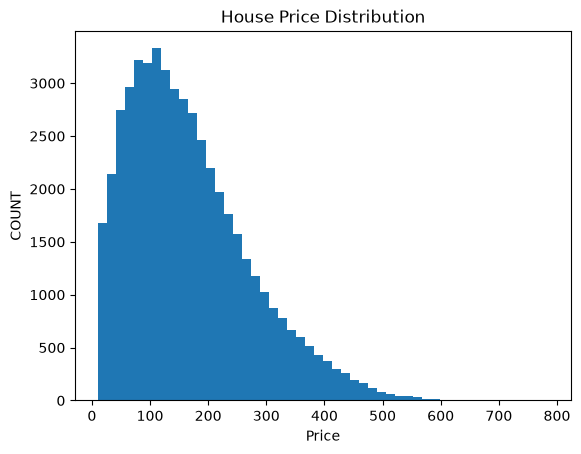

In [15]:
plt.hist(df['price_in_lakhs'], bins=50)
plt.xlabel("Price")
plt.ylabel("COUNT")
plt.title("House Price Distribution")
plt.show()

City Wise Price Analysis

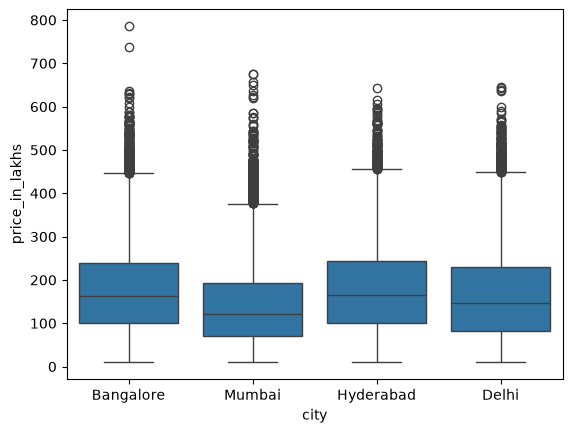

In [16]:
import seaborn as sns

sns.boxplot(
    x='city',
    y='price_in_lakhs',
    data=df
)

plt.show()

The boxplot compares house price distributions across Bangalore, Mumbai, Hyderabad, and Delhi. Hyderabad and Bangalore have slightly higher median house prices, while Mumbai shows a lower median price. All cities contain several high-priced outliers, indicating the presence of premium properties. Overall, house prices vary across cities, reflecting differences in real estate market conditions.

BHK vs Price

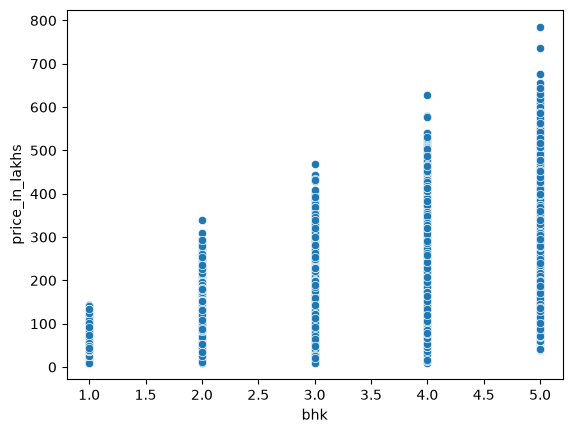

In [17]:
sns.scatterplot(
    x='bhk',
    y='price_in_lakhs',
    data=df
)

plt.show()

==>As the number of BHK increases from 1 to 5, house prices generally i     ncrease.
==>1 BHK houses are mostly available at lower prices.
==>4 BHK and 5 BHK houses have higher prices and greater price variation.
==>Some high-priced properties appear as outliers, especially in the 4 BHK and 5 BHK categories.
==>The graph indicates a positive relationship between BHK count and house price.

Built-up Area vs Price

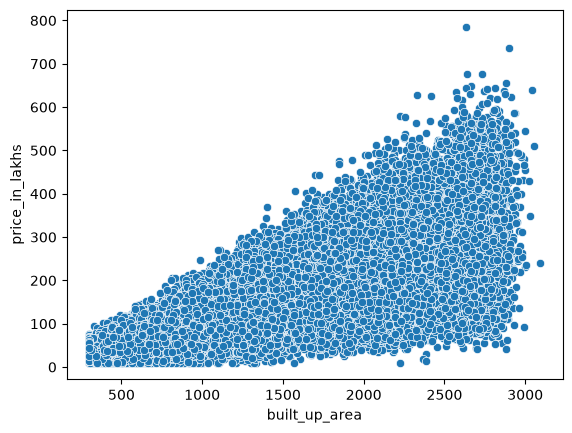

In [18]:
sns.scatterplot(
    x='built_up_area',
    y='price_in_lakhs',
    data=df
)

plt.show()

==>As the built-up area increases, house prices generally increase.
==>Smaller houses (500–1000 sq.ft.) tend to have lower prices.
==>Larger houses (2000–3000 sq.ft.) usually have higher prices.
==>The spread of points becomes wider at larger areas, indicating that ==>factors such as location, amenities, and property type also affect prices.
==>The graph shows a strong positive correlation between built-up area and house price.

PRICE DISTRIBUTION

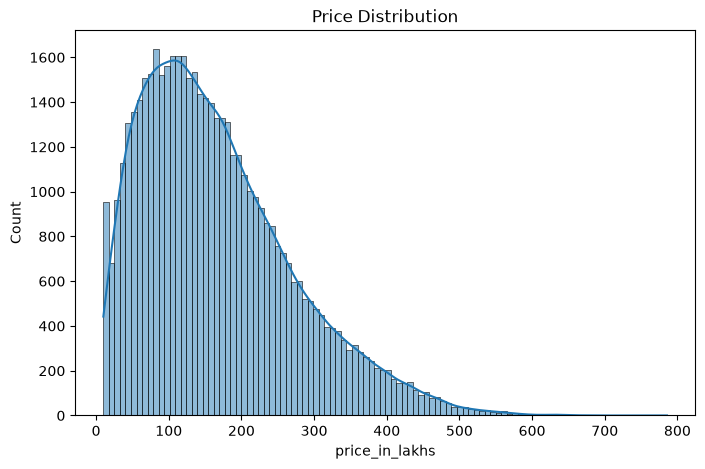

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_in_lakhs'], kde=True)
plt.title("Price Distribution")
plt.show()

==>The histogram and KDE curve show that most houses are priced between 50 and 250 lakhs.
==>The distribution is positively skewed (right-skewed), with a long tail extending toward higher prices.
==>As the price increases beyond 300 lakhs, the number of properties decreases significantly.
==>A small number of luxury properties are priced above 500 lakhs, creating the long right tail.
==>This indicates that affordable and mid-range houses dominate the market, while premium houses are relatively rare.

AVERAGE HOUSE PRICE BY CITY

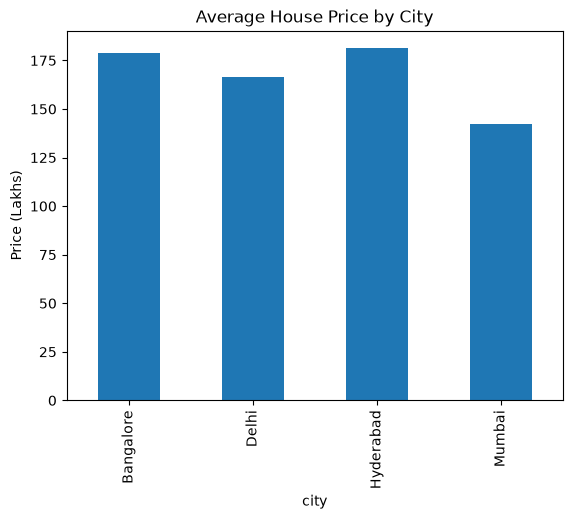

In [20]:
city_price = df.groupby('city')['price_in_lakhs'].mean()

city_price.plot(kind='bar')
plt.title("Average House Price by City")
plt.ylabel("Price (Lakhs)")
plt.show()

==>Hyderabad has the highest average house price among all cities.
==>Bangalore follows closely with the second-highest average price.
==>Delhi has a moderate average house price.
==>Mumbai has the lowest average house price in this dataset.
==>The graph highlights the variation in real estate prices across different cities.

Property Type Distribution

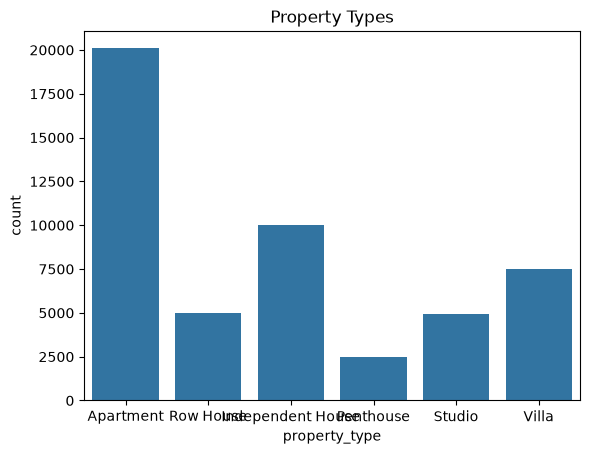

<Figure size 2400x5000 with 0 Axes>

In [21]:
sns.countplot(
    x='property_type',
    data=df
)

plt.title("Property Types")
plt.figure(figsize=(24,50))
plt.show()

==>Apartments are the most common property type, with the highest count in the dataset.
==>Independent Houses are the second most common property type.
==>Villas have a moderate presence in the market.
==>Row Houses and Studios have fewer properties.
==>Penthouses are the least common property type, indicating they are premium and less frequently available.

BHK Distribution

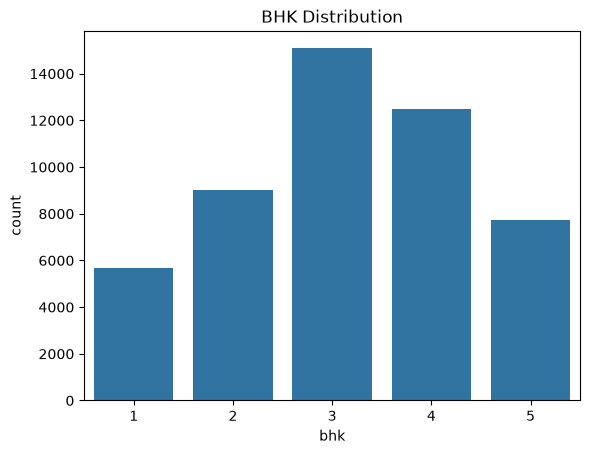

In [22]:
sns.countplot(
    x='bhk',
    data=df
)

plt.title("BHK Distribution")
plt.show()

3 BHK houses are the most common property type in the dataset.
4 BHK houses are the second most common.
2 BHK houses have a moderate presence in the market.
1 BHK and 5 BHK houses are less common compared to other categories.

PAIRPLOT

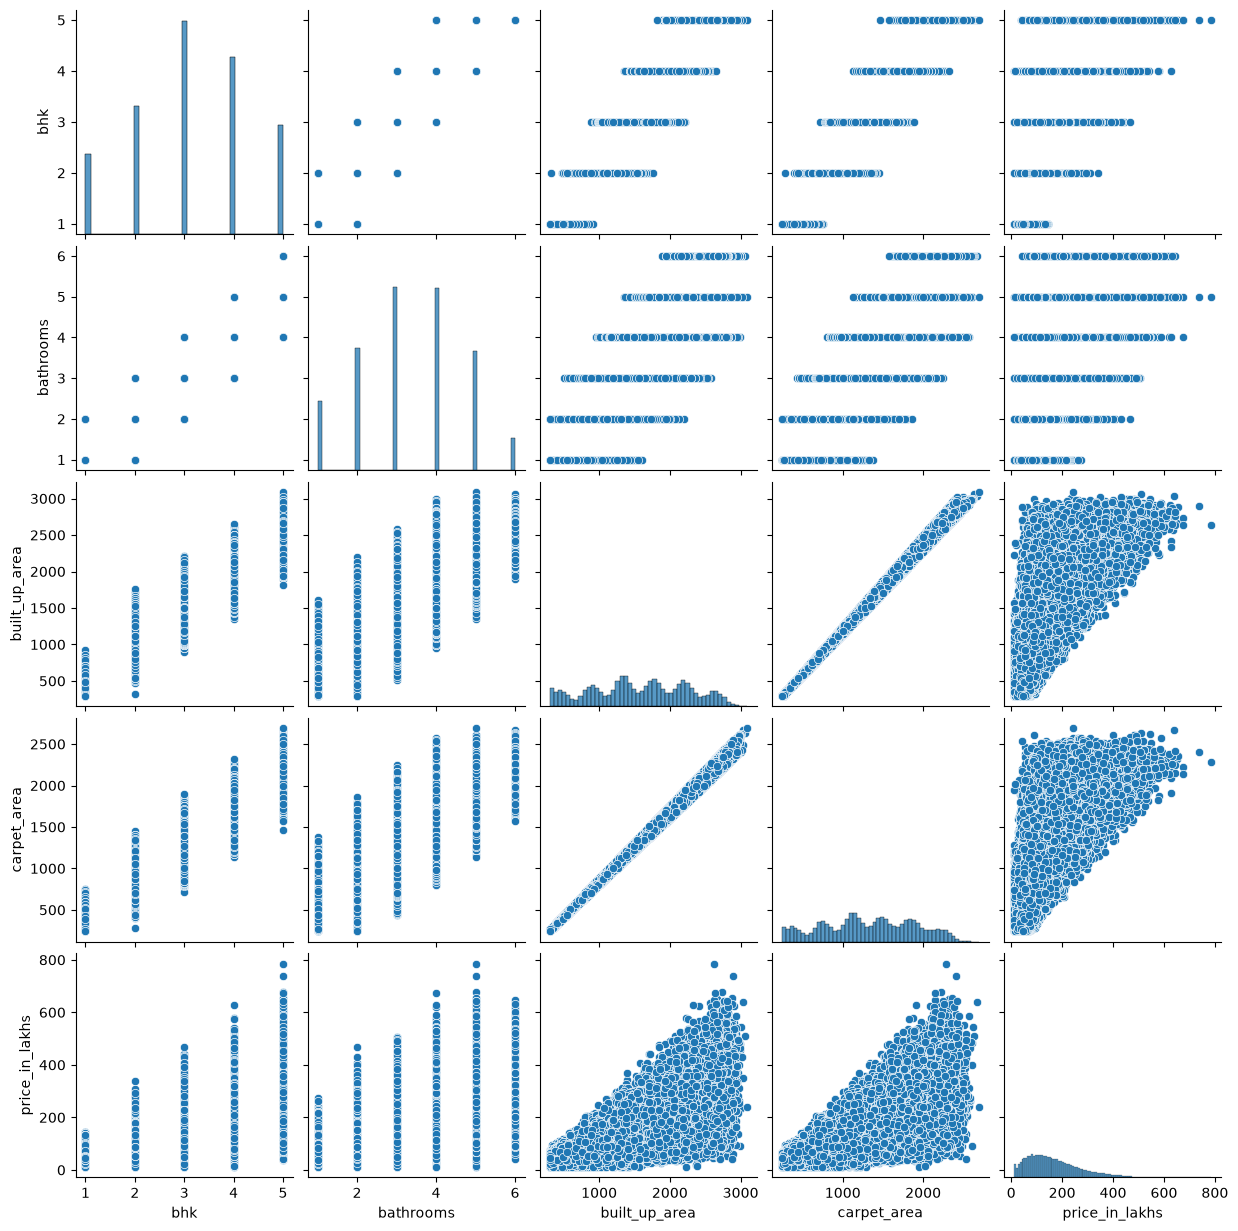

In [23]:
sample_df = df[
[
'bhk',
'bathrooms',
'built_up_area',
'carpet_area',
'price_in_lakhs'
]
]

sns.pairplot(sample_df)
plt.show()

This pair plot visualizes the relationships between BHK, bathrooms, built-up area, carpet area, and house price.
==>Built-up area and carpet area show a very strong positive correlation, indicating that larger built-up areas generally have larger carpet areas.
==>House price increases with built-up area and carpet area, showing that property size significantly influences price.
==>BHK and bathrooms also have a positive relationship with house price, meaning larger homes tend to be more expensive.

Pie Chart of Cities

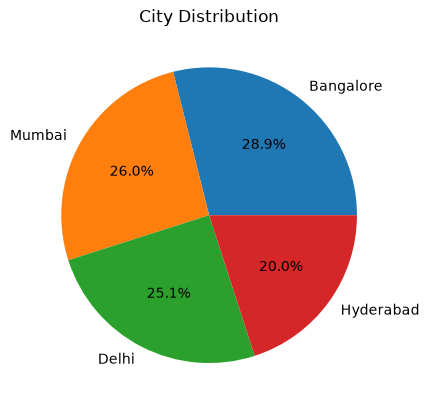

In [24]:
df['city'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("City Distribution")
plt.show()

==>Bangalore has the highest share with approximately 28.9% of the total properties.
==>Mumbai contributes around 26.0% of the properties.
==>Delhi accounts for approximately 25.1%.
==>Hyderabad has the lowest share with about 20.0% of the properties.

TOP LOCATIONS

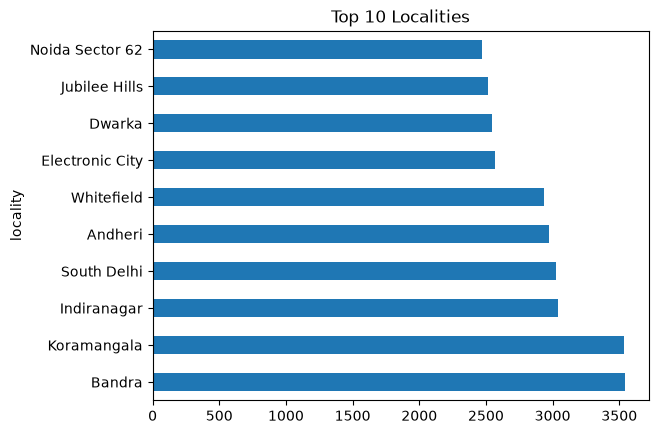

In [25]:
top_loc = df['locality'].value_counts().head(10)

top_loc.plot(kind='barh')
plt.title("Top 10 Localities")
plt.show()

==>Bandra and Koramangala have the highest number of property listings among all localities.
==>Indiranagar, South Delhi, and Andheri also have a significant number of properties.
==>Whitefield, Electronic City, Dwarka, Jubilee Hills, and Noida Sector 62 complete the top 10 list.

Correlation Heatmap

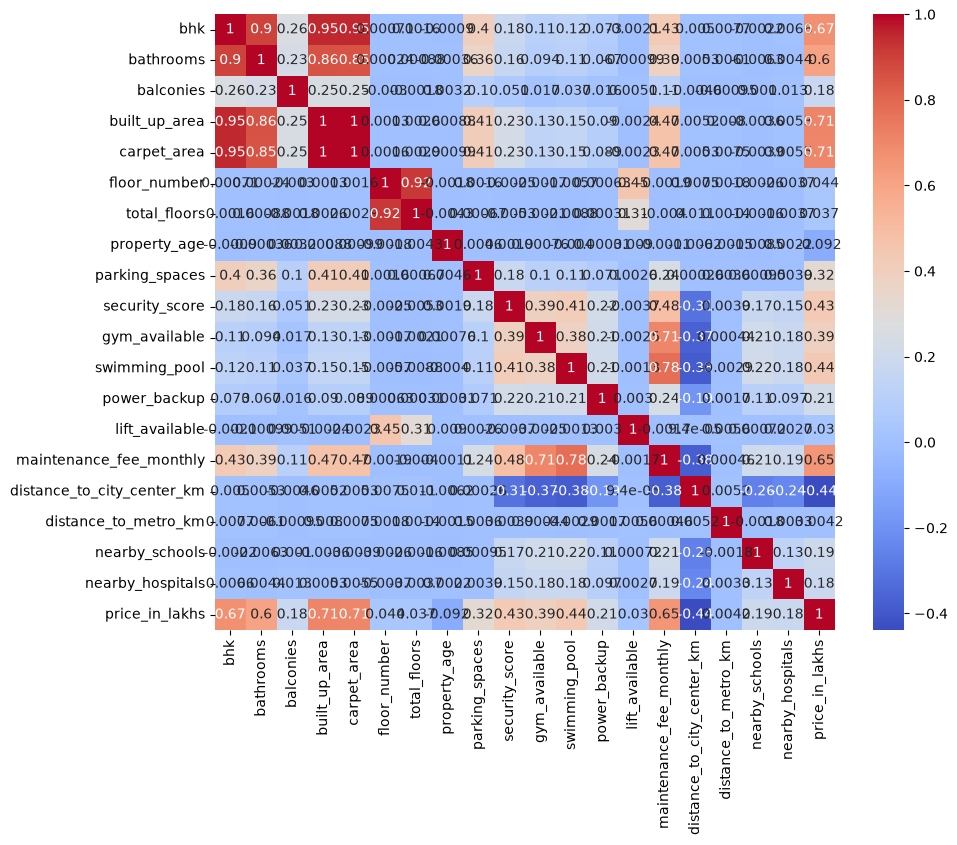

In [26]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

==>Built-up Area (0.71) and Carpet Area (0.71) have the strongest positive correlation with house price, indicating that larger properties tend to be more expensive.
==>BHK (0.67) and Bathrooms (0.60) also show strong positive correlations with house price, suggesting that bigger homes generally have higher values.
==>Maintenance Fee (0.65) is positively correlated with price, meaning premium properties often have higher maintenance costs.
==>Distance to City Center (-0.44) has a negative correlation with price, indicating that properties farther from the city center tend to be less expensive.
==>Security Score (0.43), Swimming Pool (0.44), and Gym Availability (0.39) positively influence house prices.
==>Property Age (-0.09) has a weak negative correlation, suggesting older properties may have slightly lower values.

Feature Engineering

In [27]:
X = df.drop("price_in_lakhs", axis=1)

y = df["price_in_lakhs"]

In [28]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(50000, 63)
   bhk  bathrooms  balconies  built_up_area  carpet_area  floor_number  \
0    4          4          1           1570         1361             0   
1    2          1          1            908          778             9   
2    3          3          2           1784         1568            14   
3    4          4          2           2318         2011            15   
4    3          4          2            988          840            18   

   total_floors  property_age  parking_spaces  security_score  ...  \
0             3             5               1             7.5  ...   
1            17            14               0             6.0  ...   
2            16             3               2             5.1  ...   
3            16             9               1             5.1  ...   
4            24            10               1             6.2  ...   

   facing_North-East  facing_North-West  facing_South  facing_South-East  \
0               True              False       

In [29]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='str')


train_test_split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
print(X_train.dtypes)

bhk                                 int64
bathrooms                           int64
balconies                           int64
built_up_area                       int64
carpet_area                         int64
                                    ...  
facing_West                          bool
furnishing_status_Semi-Furnished     bool
furnishing_status_Unfurnished        bool
transaction_type_Resale              bool
price_category_Low                   bool
Length: 63, dtype: object


In [32]:
df = pd.get_dummies(df)

feature selection and target variable

In [33]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop('price_in_lakhs', axis=1)
y = df['price_in_lakhs']



In [34]:
X_train.select_dtypes(include='object').columns

Index([], dtype='str')

Machine Learning Model Training

model1.Linear Regression

In [35]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(    X,
    y,
    test_size=0.2,
    random_state=42
)
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)
print("Linear Regression")

print("MAE",mean_absolute_error(y_test,y_pred_lr))
print("MSE",mean_squared_error(y_test,y_pred_lr))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print("R2",r2_score(y_test,y_pred_lr))

Linear Regression
MAE 27.941256007107178
MSE 1433.1010892318327
RMSE 37.856321654802024
R2 0.8680527732623001


model2.  DECISION TREE

In [36]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)
print("DECISION TREE")

print("MAE",mean_absolute_error(y_test,y_pred_dt))

print("MSE",mean_squared_error(y_test,y_pred_dt))

print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_dt)))

print("R2",r2_score(y_test,y_pred_dt))

DECISION TREE
MAE 33.782151
MSE 2277.14332707
RMSE 47.719422954076045
R2 0.7903408565182245


MODEL 3 . RANDOM FOREST

In [37]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit( X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("DECISION TREE")

print("MAE",mean_absolute_error(y_test,y_pred_rf))

print("MSE",mean_squared_error(y_test,y_pred_rf))

print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rf)))

print("R2",r2_score(y_test,y_pred_rf))

DECISION TREE
MAE 23.6762848
MSE 1080.0525177961722
RMSE 32.86415247341961
R2 0.9005583517275373


MODEL 4. GRADIENT BOOST

In [38]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train,y_train)

y_pred_gb = gb.predict(X_test)
print("GRADIENTBOOST")

print("MAE",mean_absolute_error(y_test,y_pred_gb))

print("MSE",mean_squared_error(y_test,y_pred_gb))

print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_gb)))

print("R2",r2_score(y_test,y_pred_gb))

GRADIENTBOOST
MAE 23.61282535205974
MSE 1046.495468982217
RMSE 32.349582207228224
R2 0.9036479868982679


MODEL 5 , XGBOOST

In [39]:
xgb = XGBRegressor(n_estimators=100,random_state=42)

xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBOOST")

print("MAE",mean_absolute_error(y_test,y_pred_xgb))

print("MSE",mean_squared_error(y_test,y_pred_xgb))

print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_xgb)))

print("R2",r2_score(y_test,y_pred_xgb))

XGBOOST
MAE 23.79724107806444
MSE 1100.6413436854477
RMSE 33.17591511451414
R2 0.8986627154055166


Model performance comparison

Illustrative R² scores across five prediction models.

In [40]:
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Decision Tree',
'Random Forest',
'Gradient Boosting',
'XGBoost'
],

'R2 Score':[

r2_score(y_test,y_pred_lr),
r2_score(y_test,y_pred_dt),
r2_score(y_test,y_pred_rf),
r2_score(y_test,y_pred_gb),
r2_score(y_test,y_pred_xgb)

]

})

print(results)

               Model  R2 Score
0  Linear Regression  0.868053
1      Decision Tree  0.790341
2      Random Forest  0.900558
3  Gradient Boosting  0.903648
4            XGBoost  0.898663


==>Gradient Boosting achieved the highest R² score (0.9036), making it the best-performing model.

Model performance comparison
Final Comparison Table

In [41]:
results = []

for model, name in [
    (lr, "Linear Regression"),
    (dt, "Decision Tree"),
    (rf, "Random Forest"),
    (gb, "Gradient Boosting"),
    (xgb, "XGBoost")]:
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, pred)

    results.append([name,mae,mse,rmse,r2])
comparison = pd.DataFrame(results,
    columns=["Model","MAE","MSE","RMSE","R2 Score"])
print(comparison)

               Model        MAE          MSE       RMSE  R2 Score
0  Linear Regression  27.941256  1433.101089  37.856322  0.868053
1      Decision Tree  33.782151  2277.143327  47.719423  0.790341
2      Random Forest  23.676285  1080.052518  32.864152  0.900558
3  Gradient Boosting  23.612825  1046.495469  32.349582  0.903648
4            XGBoost  23.797241  1100.641344  33.175915  0.898663


==>Gradient Boosting achieved the lowest MAE (23.61), indicating the smallest average prediction error.
==>Gradient Boosting also produced the lowest MSE (1046.50) and RMSE (32.35), showing superior prediction accuracy and stability.
==>The highest R² Score (0.9036) was obtained by Gradient Boosting, meaning it explains approximately 90.36% of the variance in house prices.

1.MAE (Mean Absolute Error)

Formula:  MAE=1/n ∑ ∣y actual​−y predicted​∣
Lower is better.


2.. MSE (Mean Squared Error)

Formula:  MSE=1/n ∑(y actual​−y predicted​)**2
Lower is better.

3.RMSE (Root Mean Squared Error)

Formula:  RMSE= 1/2 MSE
​
4,	​R² Score (Coefficient of Determination)

Formula: R2=1−​SS residual​​/SS total


Gradient Boosting Hyperparameter Tuning

In [42]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}

In [43]:
gbr = GradientBoostingRegressor(random_state=42)

In [44]:
# grid = GridSearchCV(
#     estimator=gbr,
#     param_grid=param_grid,
#     cv=5,
#     scoring='r2',
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(X_train, y_train)
# print("="*60)
# print("Best Parameters")
# print("="*60)

# print(grid.best_params_)

In [45]:
# best_gbr = grid.best_estimator_

COMPARISON OF ALL MODELS

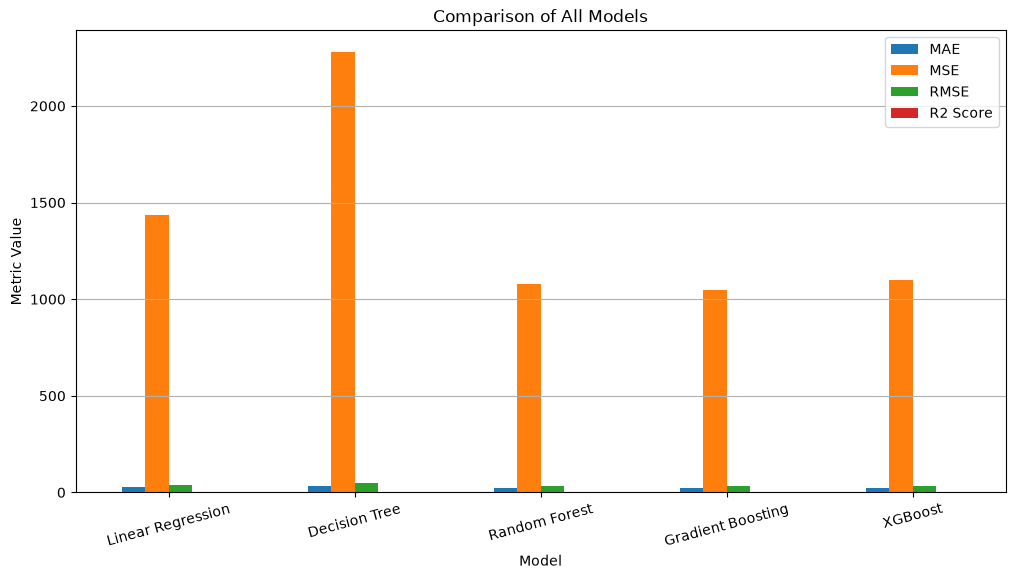

In [46]:
import matplotlib.pyplot as plt
comparison.set_index("Model").plot(kind="bar",figsize=(12,6))
plt.title("Comparison of All Models")
plt.ylabel("Metric Value")
plt.xticks(rotation=15)
plt.legend(loc="best")
plt.grid(axis="y")
plt.show()

Gradient Boosting achieved the best overall performance with the lowest MAE, MSE, and RMSE values and the highest R² Score (0.9036).

MAE COMPARISON

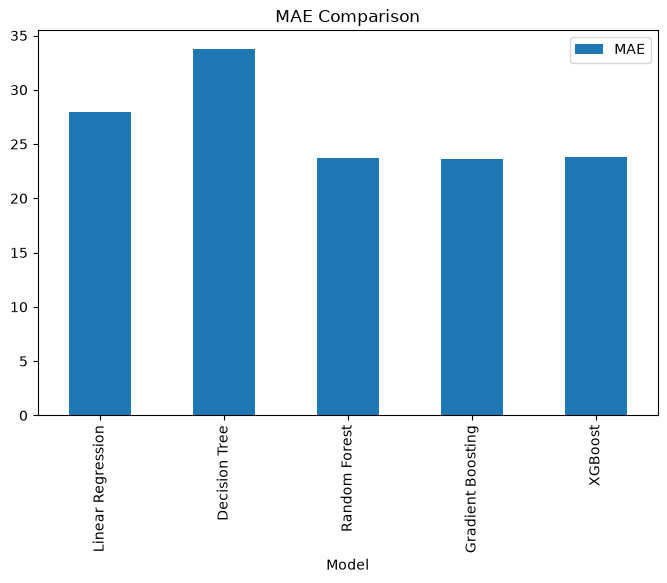

In [47]:
comparison.plot(
    x="Model",
    y="MAE",
    kind="bar",
    figsize=(8,5)
)

plt.title("MAE Comparison")
plt.show()

MSE Comparisopn

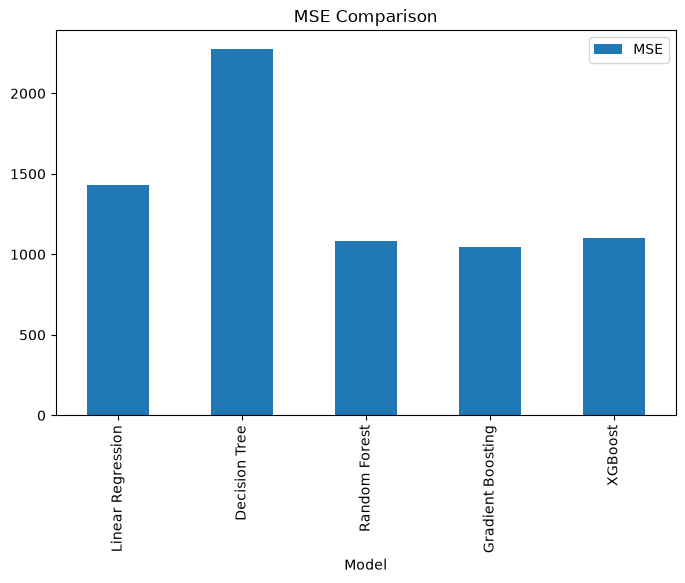

In [48]:
comparison.plot(
    x="Model",
    y="MSE",
    kind="bar",
    figsize=(8,5)
)

plt.title("MSE Comparison")
plt.show()

RMSE COMPARISON

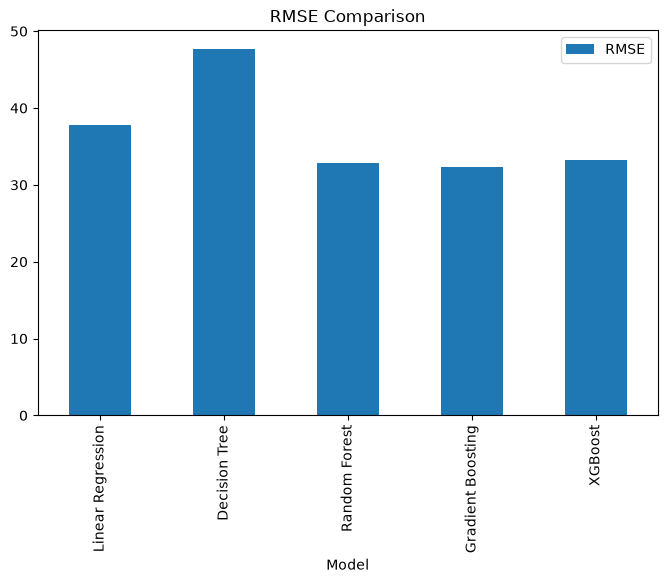

In [49]:
comparison.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(8,5)
)

plt.title("RMSE Comparison")
plt.show()

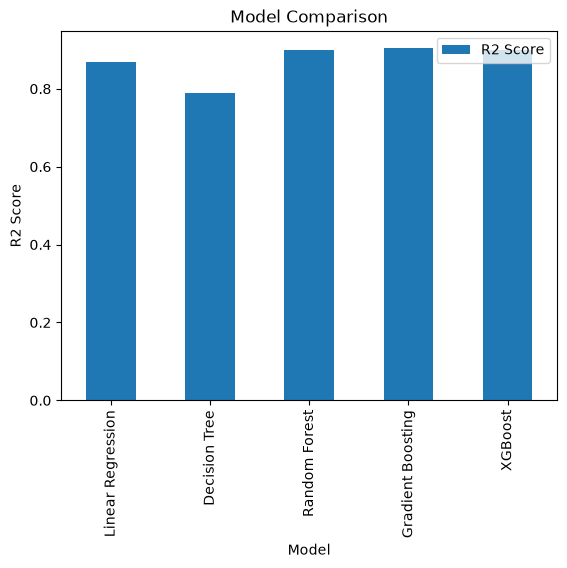

In [50]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="R2 Score",
    kind="bar"
)

plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

BEST MODEL COMPARISION BY R2 Score

In [51]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print(best_model)

Model       Gradient Boosting
MAE                 23.612825
MSE               1046.495469
RMSE                32.349582
R2 Score             0.903648
Name: 3, dtype: object


XGBoost is your best model, adding SHAP (SHapley Additive exPlanations)

In [52]:
import shap

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP explains how each feature contributes to the predicted house price. It improves model transparency and makes the AI system interpretable.

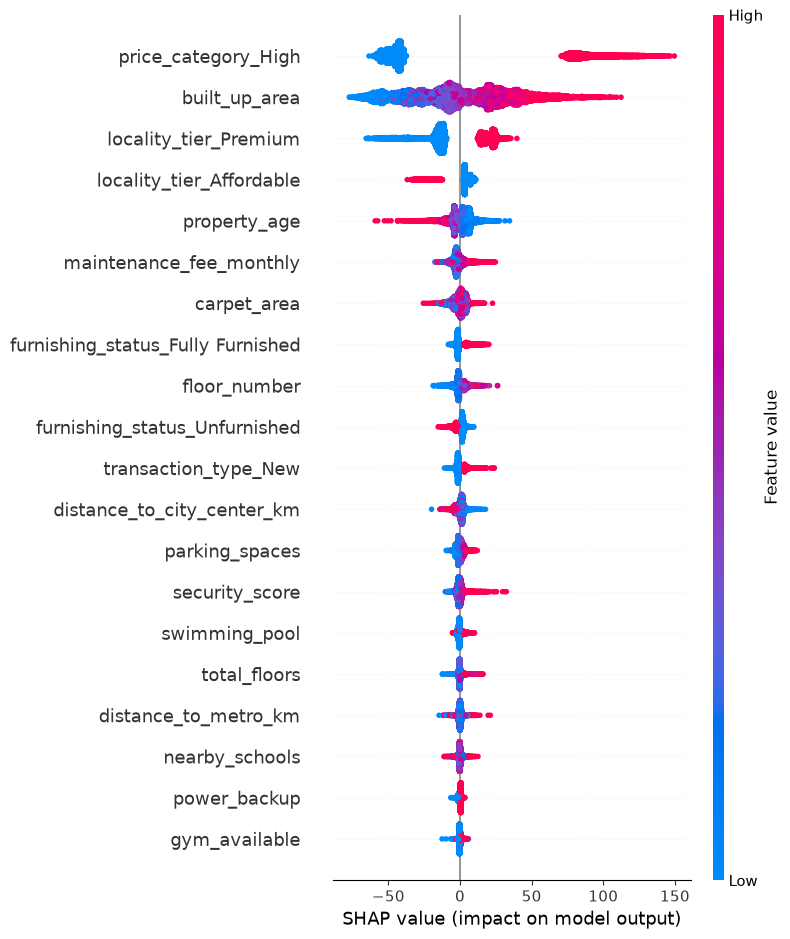

In [53]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values( X_test)
shap.summary_plot(shap_values,X_test)

The SHAP Summary Plot explains the contribution of each feature to house price predictions. Built-up area, locality tier, property age, maintenance fee, and carpet area are among the most influential factors affecting house prices. Features positioned further from zero have a greater impact on the model's predictions, improving the interpretability and transparency of the AI-powered house price prediction system.

SHAP Feature Importance

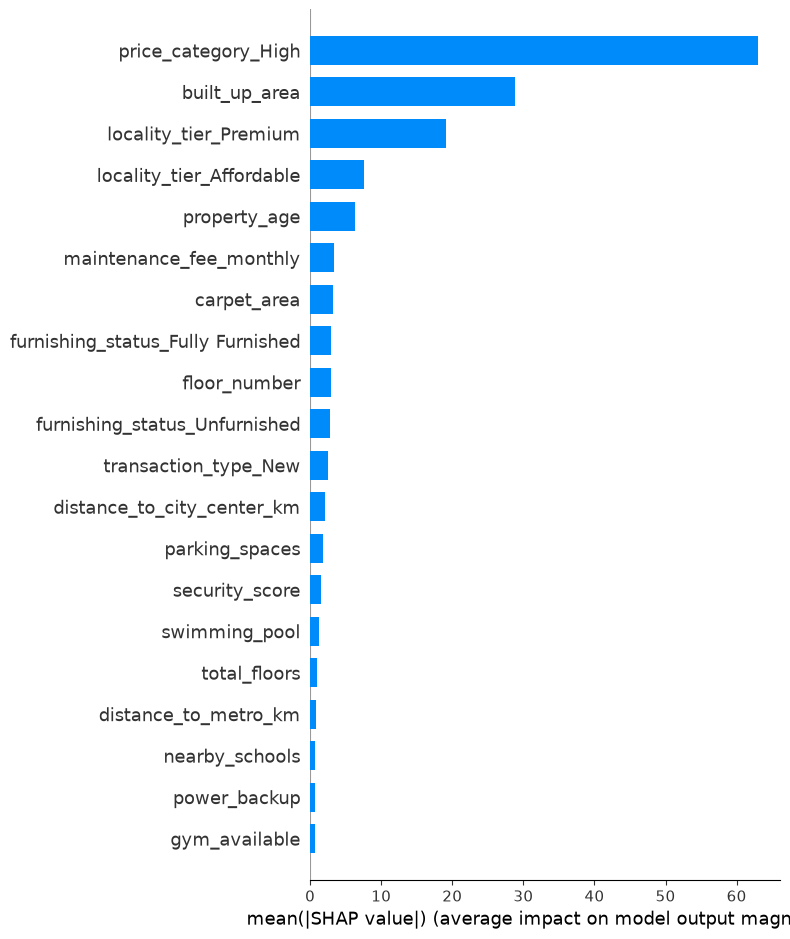

In [54]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

Predict New House Price

In [55]:
sample_house = X_test.iloc[[0]]

predicted_price = xgb.predict(sample_house)

print("Predicted Price:",predicted_price)

Predicted Price: [316.3258]


Explain This Prediction Using SHAP

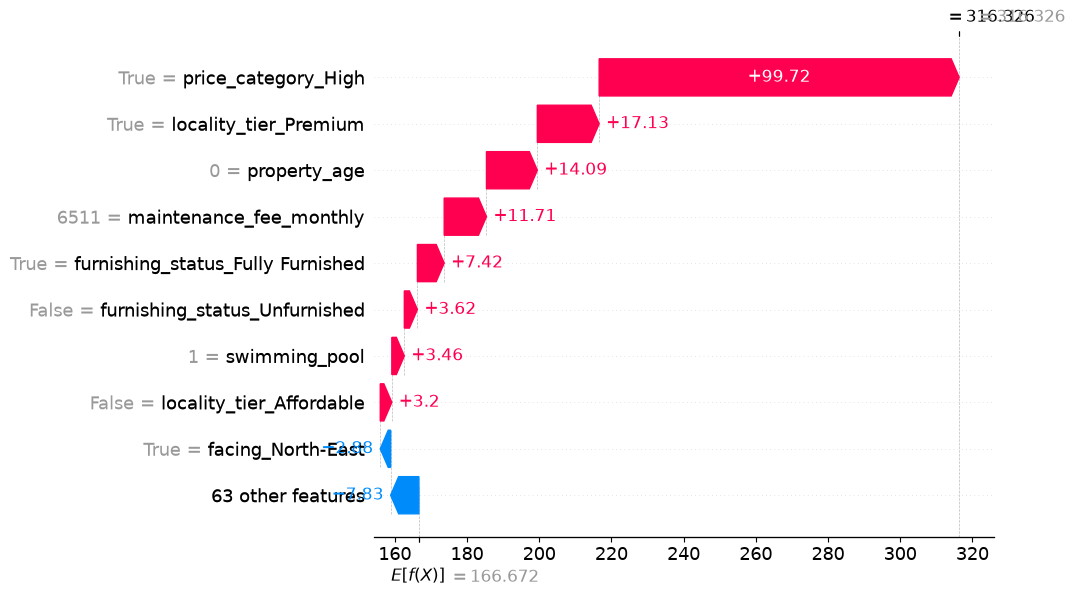

In [56]:
shap.plots.waterfall(

shap.Explanation(

values=shap_values[0],

base_values=explainer.expected_value,

data=sample_house.iloc[0],

feature_names=X_test.columns

)

)

🔺 Features Increasing the Predicted Price

price_category_High → +99.72 (largest positive impact)
locality_tier_Premium → +17.13
property_age = 0 (new property) → +14.09
maintenance_fee_monthly = 6511 → +11.71
Fully Furnished → +7.42
Swimming Pool Available → +3.46
Not in Affordable Locality → +3.20

🔻 Features Decreasing the Predicted Price

Facing North-East → -2.88
Other remaining features → -7.83
==>Prediction Process
Base Value (Average Prediction) = 166.67 Lakhs
Positive feature contributions increased the predicted price.
Negative feature contributions slightly reduced the predicted price.
Final Predicted Price = 316.33 Lakhs.

In [57]:
import joblib

joblib.dump(gb, "house_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [58]:
joblib.dump(X_train.columns.tolist(), "train_columns.pkl")
print("Training columns saved successfully.")

Training columns saved successfully.


predicting new house price


In [59]:


# print("a="*50)
# print(" HOUSE PRICE PREDICTION SYSTEM ")

# city = input("Enter City: ")
# locality = input("Enter Locality: ")
# property_type = input("Enter Property Type (Apartment/Villa): ")
# bhk = int(input("Enter BHK: "))
# bathrooms = int(input("Enter Bathrooms: "))
# built_up_area = float(input("Enter Built-up Area (sq.ft): "))
# carpet_area = float(input("Enter Carpet Area (sq.ft): "))
# furnishing_status = input("Enter Furnishing Status (Fully Furnished/Semi Furnished/Unfurnished): ")
# property_age = int(input("Enter Property Age (Years): "))
# parking_spaces = int(input("Enter Parking Spaces: "))
# distance_to_metro_km = float(input("Distance to Metro (km): "))
# distance_to_city_center_km = float(input("Distance to City Center (km): "))
# nearby_schools = int(input("Nearby Schools: "))
# nearby_hospitals = int(input("Nearby Hospitals: "))
# new_house = pd.DataFrame({
#     "city":[city],
#     "locality":[locality],
#     "property_type":[property_type],
#     "bhk":[bhk],
#     "bathrooms":[bathrooms],
#     "built_up_area":[built_up_area],
#     "carpet_area":[carpet_area],
#     "furnishing_status":[furnishing_status],
#     "property_age":[property_age],
#     "parking_spaces":[parking_spaces],
#     "distance_to_metro_km":[distance_to_metro_km],
#     "distance_to_city_center_km":[distance_to_city_center_km],
#     "nearby_schools":[nearby_schools],
#     "nearby_hospitals":[nearby_hospitals]})

# # Convert categorical variables
# new_house = pd.get_dummies(new_house)
# # Match training columns
# new_house = new_house.reindex(columns=X_train.columns, fill_value=0)
# # Predict
# predicted_price = gb.predict(new_house)
# print("\n")
# print("="*50)
# print("Predicted House Price")
# print("="*50)
# print("city                    :",city),
# print("locality                :",locality)
# print("bhk                     :",bhk)
# print("bathrooms               :",bathrooms)
# print("built_up_area           :",built_up_area)
# print("carpet_area             :",carpet_area,'\n'
#       "furnishing_status         :",furnishing_status,'\n'
#       "property_age              :",property_age,'\n'
#       "parking_spaces            :",parking_spaces,'\n'
#       "distance_to_metro_km      :",distance_to_metro_km,'\n'
#       "distance_to_city_center_km:",distance_to_city_center_km,'\n'
#       "nearby_schools            :",nearby_schools,'\n'
#       "nearby_hospitals          :",nearby_hospitals)

# print(f"Estimated House Price : ₹ {predicted_price[0]:,.2f} Lakhs")

In [60]:
# import pandas as pd

# print("="*60)
# print("      AI HOUSE PRICE PREDICTION SYSTEM")
# print("="*60)
# a
# # ---------------- CITY ----------------

# cities = ["Hyderabad","Bangalore","Mumbai","Delhi"]

# print("\nSelect City")

# for i,c in enumerate(cities,1):
#     print(f"{i}. {c}")

# city = cities[int(input("\nEnter Choice : ")) - 1]

# # ---------------- LOCALITY ----------------

# localities = {

#     "Hyderabad":[
#         "Jubilee Hills",
#         "Banjara Hills",
#         "Gachibowli",
#         "Madhapur",
#         "Kondapur"
#     ],

#     "Bangalore":[
#         "Whitefield",
#         "Electronic City",
#         "Koramangala",
#         "HSR Layout",
#         "Indiranagar"
#     ],

#     "Mumbai":[
#         "Andheri",
#         "Bandra",
#         "Powai",
#         "Borivali",
#         "Thane"
#     ],

#     "Delhi":[
#         "Dwarka",
#         "Rohini",
#         "Saket",
#         "Vasant Kunj",
#         "Karol Bagh"
#     ]

# }

# print("\nSelect Locality")

# for i,l in enumerate(localities[city],1):
#     print(f"{i}. {l}")

# locality = localities[city][int(input("\nEnter Choice : "))-1]

# # ---------------- PROPERTY TYPE ----------------

# property_types = ["Apartment","Villa"]

# print("\nSelect Property Type")

# for i,p in enumerate(property_types,1):
#     print(f"{i}. {p}")

# property_type = property_types[int(input("\nEnter Choice : "))-1]

# # ---------------- FURNISHING ----------------

# furnish = [
#     "Fully Furnished",
#     "Semi Furnished",
#     "Unfurnished"
# ]

# print("\nSelect Furnishing Status")

# for i,f in enumerate(furnish,1):
#     print(f"{i}. {f}")

# furnishing_status = furnish[int(input("\nEnter Choice : "))-1]

# # ---------------- NUMERIC INPUT ----------------

# bhk = int(input("\nEnter BHK : "))
# bathrooms = int(input("Enter Bathrooms : "))

# built_up_area = float(input("Enter Built-up Area : "))
# carpet_area = float(input("Enter Carpet Area : "))

# property_age = int(input("Enter Property Age : "))

# parking_spaces = int(input("Enter Parking Spaces : "))

# distance_to_metro_km = float(input("Distance to Metro (km): "))

# distance_to_city_center_km = float(input("Distance to City Center (km): "))

# nearby_schools = int(input("Nearby Schools : "))

# nearby_hospitals = int(input("Nearby Hospitals : "))

# # ---------------- DATAFRAME ----------------

# new_house = pd.DataFrame({

#     "city":[city],
#     "locality":[locality],
#     "property_type":[property_type],
#     "bhk":[bhk],
#     "bathrooms":[bathrooms],
#     "built_up_area":[built_up_area],
#     "carpet_area":[carpet_area],
#     "furnishing_status":[furnishing_status],
#     "property_age":[property_age],
#     "parking_spaces":[parking_spaces],
#     "distance_to_metro_km":[distance_to_metro_km],
#     "distance_to_city_center_km":[distance_to_city_center_km],
#     "nearby_schools":[nearby_schools],
#     "nearby_hospitals":[nearby_hospitals]

# })

# # One Hot Encoding

# new_house = pd.get_dummies(new_house)

# # Match Columns

# new_house = new_house.reindex(columns=X_train.columns, fill_value=0)

# # Prediction

# predicted_price = gb.predict(new_house)

# print("\n")
# print("="*60)
# print("        HOUSE PRICE PREDICTION RESULT")
# print("="*60)

# print(f"City                      : {city}")
# print(f"Locality                 : {locality}")
# print(f"Property Type            : {property_type}")
# print(f"BHK                      : {bhk}")
# print(f"Bathrooms                : {bathrooms}")
# print(f"Built-up Area (sq.ft)    : {built_up_area}")
# print(f"Carpet Area (sq.ft)      : {carpet_area}")
# print(f"Furnishing Status        : {furnishing_status}")
# print(f"Property Age (Years)     : {property_age}")
# print(f"Parking Spaces           : {parking_spaces}")
# print(f"Distance to Metro (km)   : {distance_to_metro_km}")
# print(f"Distance to City Center  : {distance_to_city_center_km}")
# print(f"Nearby Schools           : {nearby_schools}")
# print(f"Nearby Hospitals         : {nearby_hospitals}")

# print("-"*60)
# print(f"Estimated House Price    : ₹ {predicted_price[0]:,.2f} Lakhs")
# print("="*60)